In [1]:
import sys
import os
# setup work directory
current_dir = os.getcwd()
work_dir = os.path.abspath(os.path.join(current_dir, "../"))
os.chdir(work_dir)
sys.path.append(work_dir)
work_dir

'c:\\Project_HOME\\pyradar'

In [2]:
# import modules
from pyradar_sandbox.rsp.fft import range_doppler_fft
from pyradar_sandbox.utils.converter import range_bins, velocity_bins
from pyradar_sandbox.utils.vis import show_2D_heat_map


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# @Time    : 2025-03-18
# @Author  : Zhaoze Wang
# @Site    : https://github.com/Wangzhaoze/scikit-radar
# @File    : ColoRadar.py
# @IDE     : vscode
 
import os
import glob
from typing import Optional, Union
import numpy as np
 
 
Dim_Lidar: int = 4
Dim_SCRadar: int = 2
 
 
class ColoRadarDataset:
    def __init__(
        self,
        data_dir: str = 'examples/data/ColoRadar',
        scene_id: str = '2_28_2021_outdoors_run0',
    ):
        self.data_dir = data_dir
        self.scene_id = scene_id
 
    @property
    def num_frames(self):
        return NotImplementedError
 
    def load_pose(self, frame_idx: int = 0) -> np.ndarray:
        self.pose_dir = os.path.join(
            self.data_dir, self.scene_id, 'groundtruth', 'groundtruth_poses.txt'
        )
        poses = np.loadtxt(self.pose_dir)[frame_idx]
        # x, y, z, qx, qy, qz, qw = poses[0]
        return poses
 
    def load_lidar(self, frame_idx: int = 0):
        self.lidar_dir = os.path.join(
            self.data_dir, self.scene_id, 'lidar', 'pointclouds'
        )
        lidar_files = glob.glob(os.path.join(self.lidar_dir, '*.bin'))
 
        cld = np.fromfile(lidar_files[frame_idx], np.float32)
        cld = np.reshape(cld, (-1, Dim_Lidar))
 
        return cld
 
    def load_scradar(self, frame_idx: int = 0) -> np.ndarray:
        scradar_dir = os.path.join(
            self.data_dir, self.scene_id, 'single_chip', 'adc_samples', 'data'
        )
        scradar_files = glob.glob(os.path.join(scradar_dir, '*.bin'))
        data = np.fromfile(scradar_files[frame_idx], np.int16)
        data = np.reshape(
            data,
            (
                3,  # coloradar.calibration.scradar.waveform.num_tx,
                4,  # coloradar.calibration.scradar.waveform.num_rx,
                128,  # coloradar.calibration.scradar.waveform.num_chirps_per_frame,
                128,  # coloradar.calibration.scradar.waveform.num_adc_samples_per_chirp,
                2,  # I and Q signal measurements
            ),
        )
        I = np.float16(data[:, :, :, :, 0])
        Q = np.float16(data[:, :, :, :, 1])
        adc_samples = I + 1j * Q
 
        return np.array(adc_samples, dtype=np.complex64)
 
    def load_ccradar(self, frame_idx: int = 0) -> np.ndarray:
        ccradar_dir = os.path.join(
            self.data_dir, self.scene_id, 'cascade', 'adc_samples', 'data'
        )
        scradar_files = glob.glob(os.path.join(ccradar_dir, '*.bin'))
        data = np.fromfile(scradar_files[frame_idx], np.int16)
        data = np.reshape(
            data,
            (
                12,  # coloradar.calibration.ccradar.waveform.num_tx,
                16,  # coloradar.calibration.ccradar.waveform.num_rx,
                16,  # coloradar.calibration.ccradar.waveform.num_chirps_per_frame,
                256,  # coloradar.calibration.ccradar.waveform.num_adc_samples_per_chirp,
                2,  # I and Q signal measurements
            ),
        )
        I = np.float16(data[:, :, :, :, 0])
        Q = np.float16(data[:, :, :, :, 1])
        adc_samples = I + 1j * Q
 
        adc_samples = np.transpose(adc_samples, (0, 1, 3, 2))
 
        return adc_samples
 
    def load_ccradar_heatmap(self, frame_idx: int = 0):
        ccradar_heatmap_dir = os.path.join(
            self.data_dir, self.scene_id, 'cascade', 'heatmaps', 'data'
        )
        scradar_heatmap_files = glob.glob(os.path.join(ccradar_heatmap_dir, '*.bin'))
        heatmap = np.fromfile(scradar_heatmap_files[frame_idx], np.float32)
        return heatmap
 

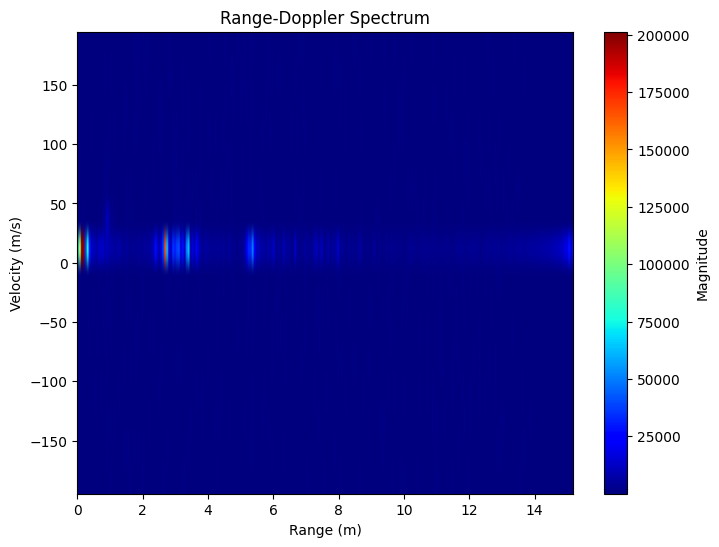

In [7]:


numSamplesPerChirps = 256
numChirpsperFrame = 16
adcSampleRate = 8000000
chirpSlope = 7.90000010527e13
startFrequency = 76999999488.0

idle_time=4.99999987369e-06
ramp_end_time=3.99999998402e-11
chirpDuration = idle_time + ramp_end_time

dataset = ColoRadarDataset()
ADC_CUBE = dataset.load_ccradar(0)
ADC_CUBE = ADC_CUBE.reshape(-1, numSamplesPerChirps, numChirpsperFrame)
# Perform Range-Doppler FFT on the ADC cube
rd_spectrum = range_doppler_fft(ADC_CUBE, IdxSamples=1, IdxChirps=2)

# Calculate the range axis and velocity axis based on waveform parameters
range_axis = range_bins(
    numSamplesPerChirps, adcSampleRate, chirpSlope=chirpSlope
)
velocity_axis = velocity_bins(
    numChirpsperFrame, startFrequency, chirpDuration
)

rd_spectrum = np.transpose(rd_spectrum, (0, 2, 1))
# Display the 2D heatmap of the Range-Doppler spectrum
show_2D_heat_map(
    rd_spectrum[0][::-1], 
    xlabel='Range (m)',
    xaxis=range_axis,
    ylabel='Velocity (m/s)',
    yaxis=velocity_axis,
    title='Range-Doppler Spectrum',
)
